# Importing Essential Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.svm import SVR

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, SequentialFeatureSelector


# Classification

## Loading Dataset for Classification

In [2]:
classification_df = pd.read_csv('../data/breastAltered.csv')

In [3]:
classification_df.head(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302.0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517.0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903.0,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301.0,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [4]:
classification_df.tail(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
565,926682.0,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954.0,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241.0,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751.0,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


## Inspection of Dataset for Classification

- Dataset Creator
> The dataset was created by William Wolberg, Olvi Mangasarian, Nick Street, W.Street.

- Dataset Source
> Kaggle Website

In [5]:
classification_df.columns # all the columns in the dataset

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

**Dataset Objective**
> The objective of the dataset is to predict whether a person has breast cancer or not based on the various medical factors like: size of the breast lump, smoothness, radius and other features.

**Dataset Status**
> The dataset contains 32 columns. Each column has different purpose except for one column which is used for the numbering of the dataset training examples.



In [6]:
classification_df.size

18208

In [7]:
classification_df.info(verbose = False)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Columns: 32 entries, id to fractal_dimension_worst
dtypes: float64(31), str(1)
memory usage: 142.4 KB


## Data Cleaning

### Searching for Missing Values and Duplicate Columns

In [8]:
classification_df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               3
perimeter_mean             0
area_mean                  1
smoothness_mean            3
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  3
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          4
symmetry_se                2
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            5
area_worst                 0
smoothness_worst           2
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             2
fractal_dimension_worst    0
dtype: int64

In [9]:
classification_df.isnull().sum().sum()

np.int64(25)

In [10]:
classification_df.duplicated().sum()

np.int64(0)

**Columns with Missing Values**
- texture_mean
- area_mean
- smoothness_mean
- radius_se
- concave points_se
- symmetry_se
- perimeter_worst
- smoothness_worst
- symmetry_worst

### Cleaning the Numerical Columns Using the Data Imputation Techniques (mean, median)

In [11]:
classification_df.drop(columns = 'id', inplace = True)

In [12]:
classification_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [13]:
classification_df.select_dtypes(include = np.number).isnull().sum()

radius_mean                0
texture_mean               3
perimeter_mean             0
area_mean                  1
smoothness_mean            3
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  3
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          4
symmetry_se                2
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            5
area_worst                 0
smoothness_worst           2
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             2
fractal_dimension_worst    0
dtype: int64

In [14]:
classification_df[classification_df['texture_mean'].isnull()]

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
102,B,12.180,NaN,77.22,458.7,0.08013,0.04038,0.02383,0.01770,0.1739,...,13.340,32.84,84.58,547.8,0.1123,0.08862,0.11450,0.07431,0.2694,0.06878
358,B,8.878,NaN,56.74,241.0,0.08293,0.07698,0.04721,0.02381,0.1930,...,9.981,17.70,65.27,302.0,0.1015,0.12480,0.09441,0.04762,0.2434,0.07431
451,M,19.590,NaN,127.70,1191.0,0.10320,0.09871,0.16550,0.09063,0.1663,...,21.440,30.96,139.80,1421.0,0.1528,0.18450,0.39770,0.14660,0.2293,0.06091


In [15]:
print("Min Value of texture mean:", classification_df['texture_mean'].min())
print("Max value of texture mean", classification_df['texture_mean'].max())

Min Value of texture mean: 9.71
Max value of texture mean 39.28


In [16]:
classification_df['texture_mean'] = classification_df['texture_mean'].fillna(value = classification_df['texture_mean'].mean())
classification_df['texture_mean'].isnull().sum()

np.int64(0)

In [17]:
classification_df[classification_df['area_mean'].isnull()]

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
30,M,18.63,25.11,124.8,NaN,0.1064,0.1887,0.2319,0.1244,0.2183,...,23.15,34.01,160.5,1670.0,0.1491,0.4257,0.6133,0.1848,0.3444,0.09782


In [18]:
print("Min Value of area mean:", classification_df['area_mean'].min())
print("Max value of area mean", classification_df['area_mean'].max())

Min Value of area mean: 143.5
Max value of area mean 2501.0


In [19]:
classification_df['area_mean'] = classification_df['area_mean'].fillna(value = classification_df['area_mean'].mean())
classification_df['area_mean'].isnull().sum()

np.int64(0)

In [20]:
print(f"smoothness mean => min: {classification_df['smoothness_mean'].min()}, max: {classification_df['smoothness_mean'].max()}")
print(f"radius_se => min: {classification_df['radius_se'].min()}, max: {classification_df['radius_se'].max()}")
print(f"concave points_se => min: {classification_df['concave points_se'].min()}, max: {classification_df['concave points_se'].max()}")
print(f"symmetry => min: {classification_df['symmetry_se'].min()}, max: {classification_df['symmetry_se'].max()}")
print(f"perimeter_worst => min: {classification_df['perimeter_worst'].min()}, max: {classification_df['perimeter_worst'].max()}")
print(f"symmetry_worst => min: {classification_df['symmetry_worst'].min()}, max: {classification_df['symmetry_worst'].max()}")
print(f"symmetry_se => min: {classification_df['symmetry_se'].min()}, max: {classification_df['symmetry_se'].max()}")


smoothness mean => min: 0.05263, max: 0.1634
radius_se => min: 0.1115, max: 2.873
concave points_se => min: 0.0, max: 0.05279
symmetry => min: 0.007882, max: 0.07895
perimeter_worst => min: 50.41, max: 251.2
symmetry_worst => min: 0.1565, max: 0.6638
symmetry_se => min: 0.007882, max: 0.07895


In [21]:
classification_df['smoothness_mean'] = classification_df['smoothness_mean'].fillna(value = classification_df['smoothness_mean'].mean())
classification_df['concave points_se'] = classification_df['concave points_se'].fillna(value = classification_df['concave points_se'].mean())
classification_df['symmetry_worst'] = classification_df['symmetry_worst'].fillna(value = classification_df['symmetry_worst'].mean())

classification_df[['smoothness_mean', 'concave points_se', 'symmetry_worst']].isnull().sum()

smoothness_mean      0
concave points_se    0
symmetry_worst       0
dtype: int64

In [22]:
classification_df['radius_se'] = classification_df['radius_se'].fillna(value = classification_df['radius_se'].mean())
classification_df['symmetry_se'] = classification_df['symmetry_se'].fillna(value = classification_df['symmetry_se'].mean())
classification_df['perimeter_worst'] = classification_df['perimeter_worst'].fillna(value = classification_df['perimeter_worst'].mean())
classification_df['smoothness_worst'] = classification_df['smoothness_worst'].fillna(value = classification_df['smoothness_worst'].mean())

classification_df[['radius_se', 'symmetry_se', 'perimeter_worst', 'smoothness_worst']].isnull().sum()

radius_se           0
symmetry_se         0
perimeter_worst     0
smoothness_worst    0
dtype: int64

In [23]:
classification_df.isnull().sum().sum()

np.int64(0)

### Cleaning Categorical Columns


In [ ]:
classification_df.select_dtypes(exclude=np.number).isnull().sum()

#What can be used for filling up categorical missing variables?
# ffill() or bfill()
# mode

diagnosis    0
dtype: int64

### Summary Statistics

#### For Numerical Columns

In [26]:
classification_df.select_dtypes(include = np.number).head(2)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [28]:
Cnumeric_cols = classification_df.select_dtypes(include = np.number)
print("Variance of the Different Columns: \n", Cnumeric_cols.var())

# Variance helps in determining how far each data point is from the mean in the column

Variance of the Different Columns: 
 radius_mean                    12.418920
texture_mean                   18.413386
perimeter_mean                590.440480
area_mean                  123512.717515
smoothness_mean                 0.000197
compactness_mean                0.002789
concavity_mean                  0.006355
concave points_mean             0.001506
symmetry_mean                   0.000752
fractal_dimension_mean          0.000050
radius_se                       0.076835
texture_se                      0.304316
perimeter_se                    4.087896
area_se                      2069.431583
smoothness_se                   0.000009
compactness_se                  0.000321
concavity_se                    0.000911
concave points_se               0.000038
symmetry_se                     0.000068
fractal_dimension_se            0.000007
radius_worst                   23.360224
texture_worst                  37.776483
perimeter_worst              1116.211358
area_worst          

In [29]:
Cnumeric_cols.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.284099,91.969033,654.126585,0.096309,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.174947,880.583128,0.132326,0.254265,0.272188,0.114606,0.290302,0.083946
std,3.524049,4.291082,24.298981,351.443762,0.014032,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.409749,569.356993,0.022771,0.157336,0.208624,0.065732,0.061749,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.180000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.160000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250600,0.071460
50%,13.370000,18.870000,86.240000,551.100000,0.095920,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.820000,686.500000,0.131400,0.211900,0.226700,0.099930,0.282600,0.080040
75%,15.780000,21.780000,104.100000,782.600000,0.105100,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.000000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


#### For Categorical Columns

In [30]:
Ccategorical_cols = classification_df.select_dtypes(exclude = np.number)
Ccategorical_cols

,diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


In [32]:
Ccategorical_cols['diagnosis'].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

In [33]:
Ccategorical_cols['diagnosis'].mode()

0    B
Name: diagnosis, dtype: str

### Data Visualization and Interpretation

#### Univariate Analysis

##### Histogram (Raduis of the tumor)

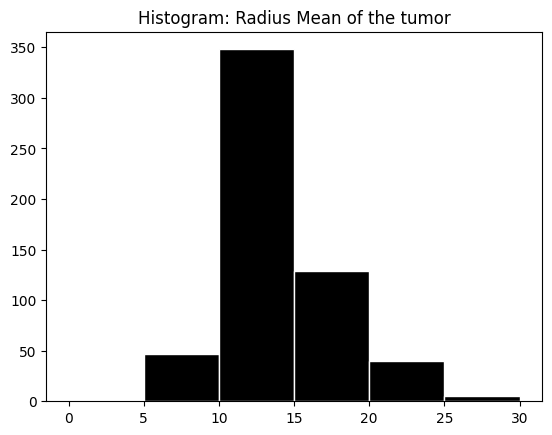

In [40]:
bins = [0, 5, 10, 15, 20, 25, 30]

plt.hist(x = classification_df['radius_mean'], bins = bins, color = "#000", edgecolor = "#fff")

plt.title("Histogram: Radius Mean of the tumor")
plt.show()

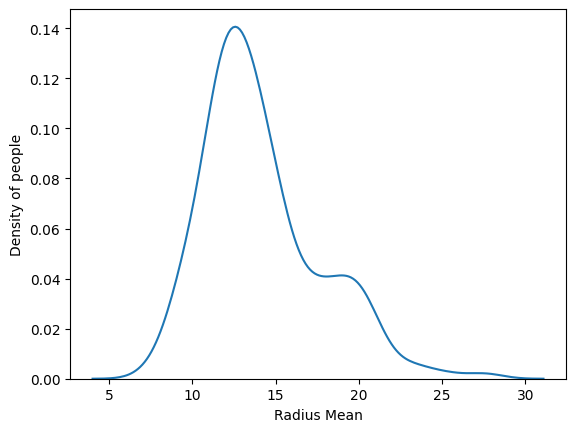

In [ ]:
sns.kdeplot(classification_df, x = 'radius_mean')

plt.xlabel("Radius Mean")
plt.ylabel("Density of people")
plt.show()


- Right Skewed Data as the tail of the kde plot is towards right
- Mean > Median > Mode
- Modality Distribution => Unimodal as there's only one peak in the histogram

##### Barplot (Diagnosis - Target Variable)

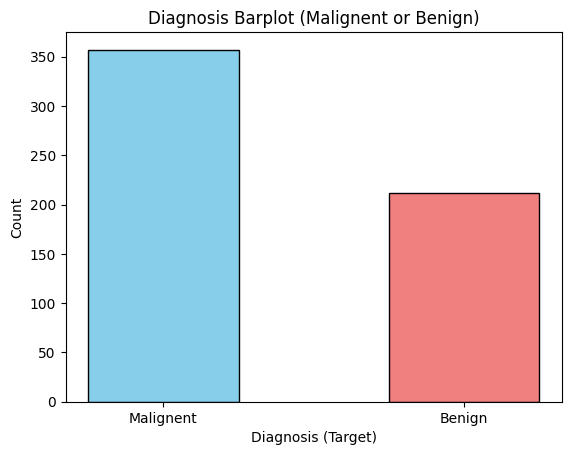

In [78]:
values = []

labels = ["Malignent", "Benign"]

plt.bar(labels, classification_df['diagnosis'].value_counts(), color = ['skyblue', 'lightcoral'], width=0.5, edgecolor = "000")

plt.title("Diagnosis Barplot (Malignent or Benign)")
plt.ylabel("Count")
plt.xlabel("Diagnosis (Target)")
plt.show()


##### Box plot (Radius Worst)

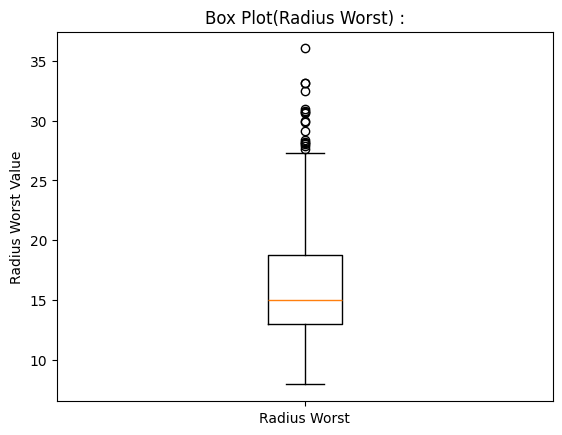

In [87]:
plt.boxplot(classification_df['radius_worst'], tick_labels = ['Radius Worst',])

plt.title("Box Plot(Radius Worst) :")
plt.ylabel("Radius Worst Value")
plt.show()

#### Bivariate Analysis

# Regression